Dataset carregado de: oasis_longitudinal.csv


/tmp/ipykernel_152/2269658278.py:53: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Diagnostico"] = df["Diagnostico"].replace({
/tmp/ipykernel_152/2269658278.py:58: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Sexo"] = df["Sexo"].replace({"M": 0, "F": 1})


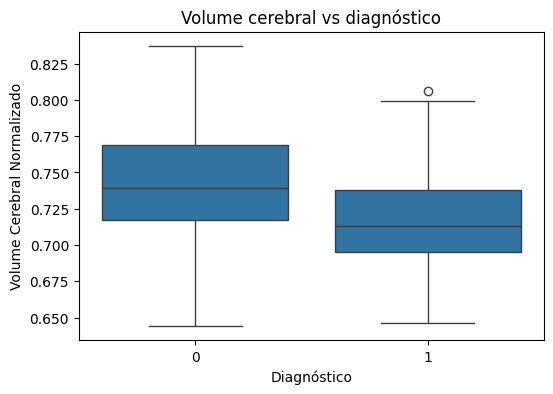

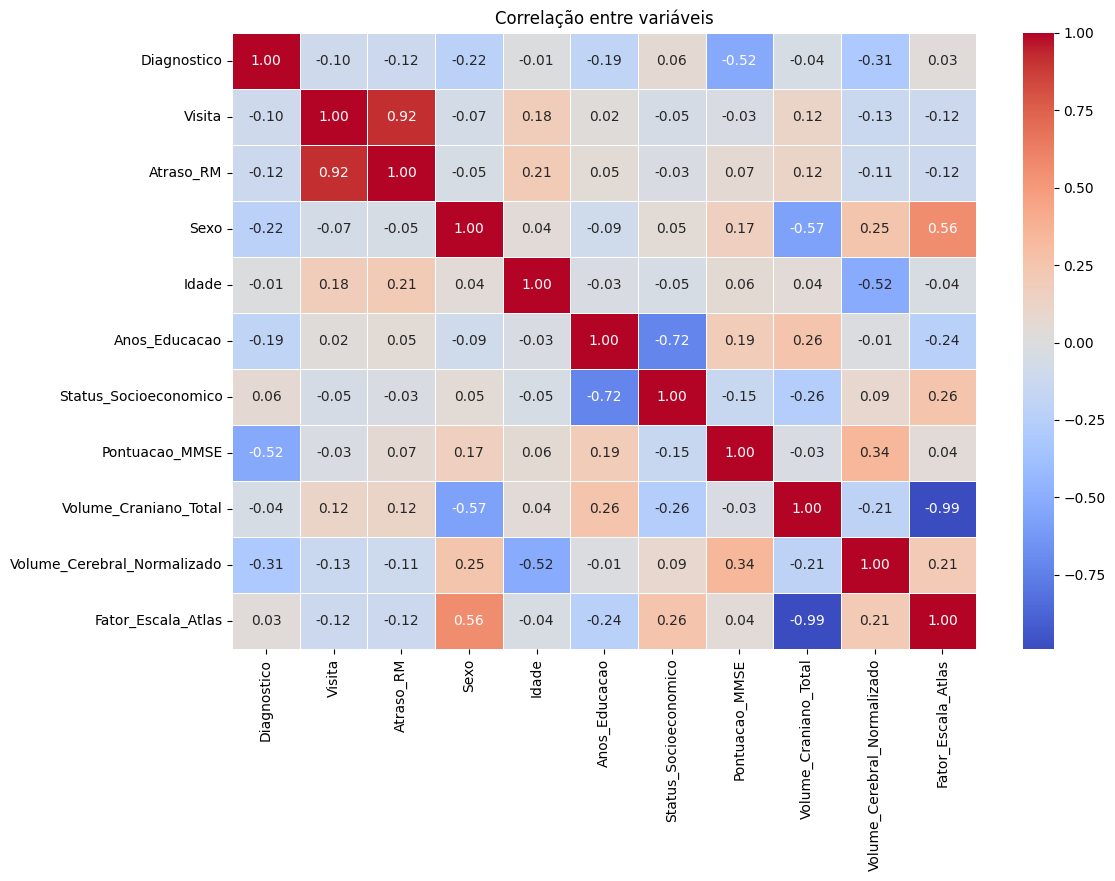

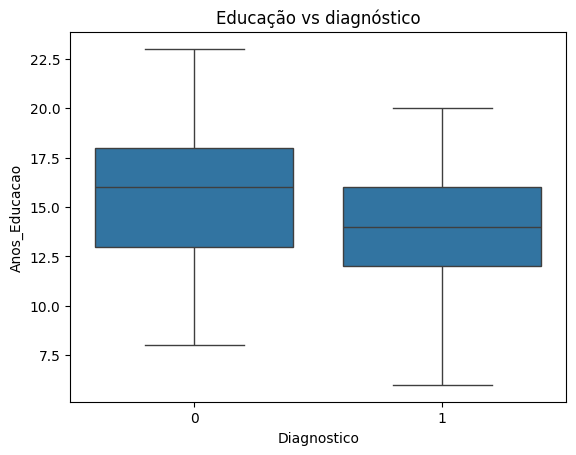

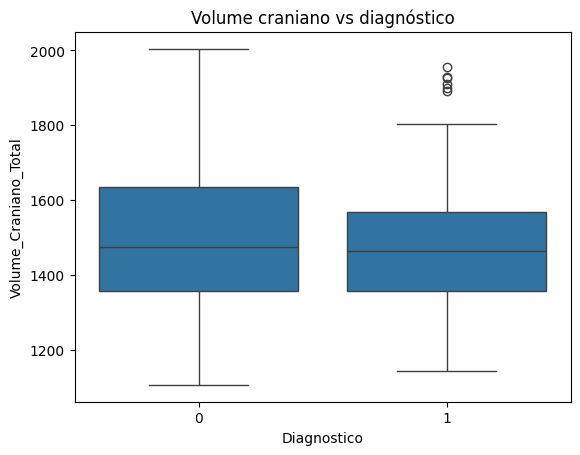


Perceptron
              precision    recall  f1-score   support

           0       0.80      0.63      0.71        38
           1       0.69      0.84      0.76        37

    accuracy                           0.73        75
   macro avg       0.74      0.73      0.73        75
weighted avg       0.75      0.73      0.73        75

Coeficientes: [[ -2.78012807   2.72183579  -3.41039136  -2.29847535  -0.85360133
   -4.00884891 -10.06428411  -5.3944986   -0.94588032  -1.76801515]]
Bias: [3.]

Árvore de decisão
              precision    recall  f1-score   support

           0       0.73      0.71      0.72        38
           1       0.71      0.73      0.72        37

    accuracy                           0.72        75
   macro avg       0.72      0.72      0.72        75
weighted avg       0.72      0.72      0.72        75

Accuracy: 0.72

Melhores parâmetros da árvore: {'model__criterion': 'gini', 'model__max_depth': 10, 'model__min_samples_split': 12}
              precisio

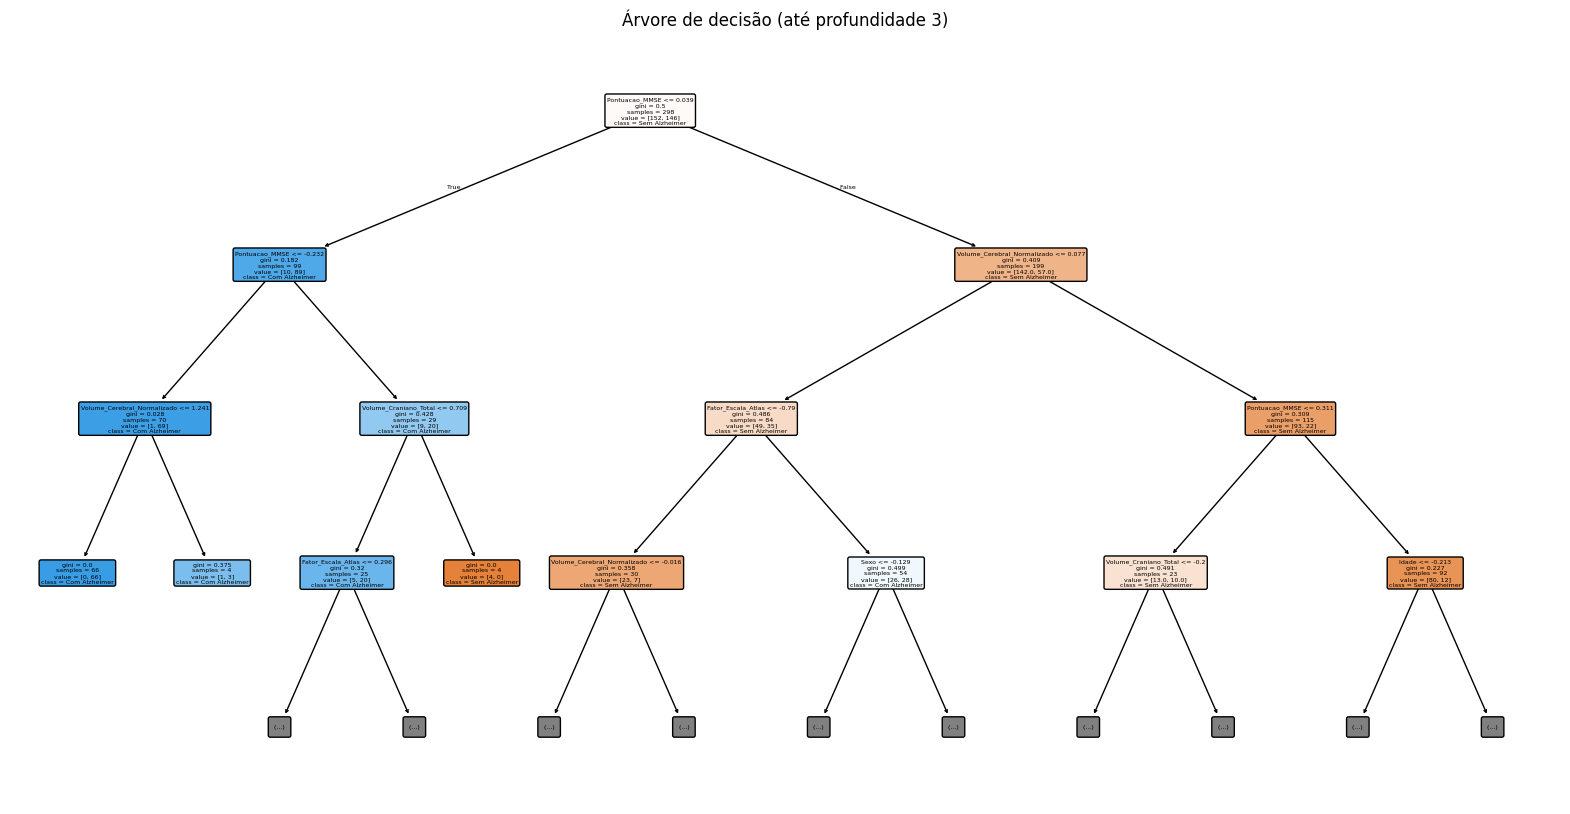


Random Forest
              precision    recall  f1-score   support

           0       0.71      0.89      0.79        38
           1       0.85      0.62      0.72        37

    accuracy                           0.76        75
   macro avg       0.78      0.76      0.75        75
weighted avg       0.78      0.76      0.76        75


Importância das variáveis
                       feature  importance
6               Pontuacao_MMSE    0.300530
8  Volume_Cerebral_Normalizado    0.156147
7        Volume_Craniano_Total    0.123088
9           Fator_Escala_Atlas    0.115774
3                        Idade    0.086007
4                Anos_Educacao    0.073113
1                    Atraso_RM    0.047682
2                         Sexo    0.039012
5        Status_Socioeconomico    0.037654
0                       Visita    0.020993


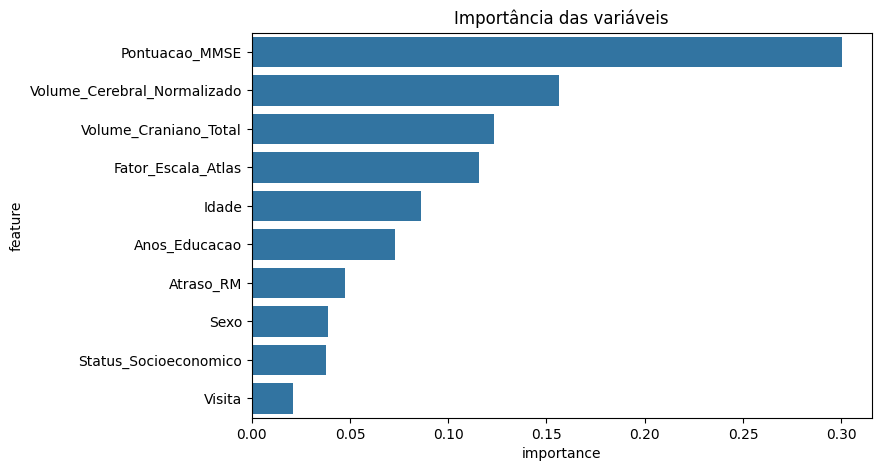

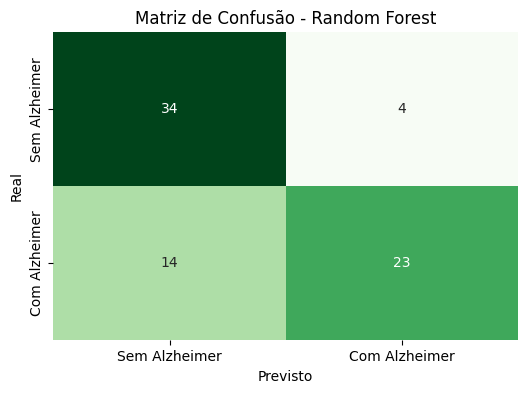


Comparação de modelos
          Modelo  Accuracy  F1 Score
0     Perceptron  0.733333  0.756098
1  Decision Tree  0.720000  0.720000
2  Random Forest  0.760000  0.718750


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Perceptron
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


# Carregamento do dataset
df = pd.read_csv("oasis_longitudinal.csv")
DATA_PATH = "data/oasis_longitudinal.csv"

if not os.path.exists(DATA_PATH):
    DATA_PATH = "oasis_longitudinal.csv"

df = pd.read_csv(DATA_PATH)
print("Dataset carregado de:", DATA_PATH)

# Renomeação das colunas
df = df.rename(columns={
    "Group": "Diagnostico",
    "Visit": "Visita",
    "MR Delay": "Atraso_RM",
    "M/F": "Sexo",
    "Hand": "Dominancia_Mao",
    "Age": "Idade",
    "EDUC": "Anos_Educacao",
    "SES": "Status_Socioeconomico",
    "MMSE": "Pontuacao_MMSE",
    "CDR": "Escala_CDR",
    "eTIV": "Volume_Craniano_Total",
    "nWBV": "Volume_Cerebral_Normalizado",
    "ASF": "Fator_Escala_Atlas"
})

# Conversão da variável alvo
df["Diagnostico"] = df["Diagnostico"].replace({
    "Nondemented": "Sem Alzheimer",
    "Demented": "Com Alzheimer",
    "Converted": "Com Alzheimer"
})

df["Diagnostico"] = df["Diagnostico"].replace({
    "Sem Alzheimer": 0,
    "Com Alzheimer": 1
})

df["Sexo"] = df["Sexo"].replace({"M": 0, "F": 1})

# Remoção de colunas não utilizadas
df = df.drop(columns=["Subject ID", "MRI ID", "Dominancia_Mao", "Escala_CDR"])



# Análise exploratória

plt.figure(figsize=(6,4))
sns.boxplot(x=df["Diagnostico"], y=df["Volume_Cerebral_Normalizado"])
plt.xlabel("Diagnóstico")
plt.ylabel("Volume Cerebral Normalizado")
plt.title("Volume cerebral vs diagnóstico")
plt.show()


correlation = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title('Correlação entre variáveis')
plt.show()


sns.boxplot(x='Diagnostico', y='Anos_Educacao', data=df)
plt.title('Educação vs diagnóstico')
plt.show()


sns.boxplot(x='Diagnostico', y='Volume_Craniano_Total', data=df)
plt.title('Volume craniano vs diagnóstico')
plt.show()



# Separação treino / teste

X = df.drop(columns=["Diagnostico"])
y = df["Diagnostico"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



# Pipeline de preprocessamento

numeric_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features)
    ]
)



# Baseline - Perceptron

baseline_pipeline = Pipeline([
    ('prepro', preprocessor),
    ('model', Perceptron(random_state=42))
])

baseline_pipeline.fit(X_train, y_train)
y_pred_base = baseline_pipeline.predict(X_test)

print("\nPerceptron")
print(classification_report(y_test, y_pred_base))
print("Coeficientes:", baseline_pipeline.named_steps['model'].coef_)
print("Bias:", baseline_pipeline.named_steps['model'].intercept_)



# Árvore de decisão

tree_pipeline = Pipeline([
    ('prepro', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

tree_pipeline.fit(X_train, y_train)
y_pred_tree = tree_pipeline.predict(X_test)

print("\nÁrvore de decisão")
print(classification_report(y_test, y_pred_tree))
print("Accuracy:", accuracy_score(y_test, y_pred_tree))



# Grid Search na árvore

param_grid_tree = {
    'model__max_depth': [3,5,10,None],
    'model__min_samples_split': [10,12],
    'model__criterion': ['gini','entropy']
}

grid_tree = GridSearchCV(
    tree_pipeline,
    param_grid_tree,
    cv=StratifiedKFold(n_splits=5),
    scoring='f1',
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)

best_tree = grid_tree.best_estimator_
y_pred_best_tree = best_tree.predict(X_test)

print("\nMelhores parâmetros da árvore:", grid_tree.best_params_)
print(classification_report(y_test, y_pred_best_tree))


# Visualização da árvore

tree_model = best_tree.named_steps["model"]

plt.figure(figsize=(20,10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Sem Alzheimer","Com Alzheimer"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Árvore de decisão (até profundidade 3)")
plt.show()



# Random Forest

rf_pipeline = Pipeline([
    ('prepro', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

param_dist_rf = {
    'model__n_estimators': [100,200,300],
    'model__max_features': ['sqrt','log2'],
    'model__max_depth': [5,10,20,None],
    'model__bootstrap': [True,False]
}

random_rf = RandomizedSearchCV(
    rf_pipeline,
    param_dist_rf,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

random_rf.fit(X_train, y_train)

y_pred_rf = random_rf.predict(X_test)

print("\nRandom Forest")
print(classification_report(y_test, y_pred_rf))



# Importância das variáveis

best_rf = random_rf.best_estimator_

importances = best_rf.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nImportância das variáveis")
print(importance_df)


plt.figure(figsize=(8,5))
sns.barplot(
    data=importance_df,
    x="importance",
    y="feature"
)
plt.title("Importância das variáveis")
plt.show()


# Matriz de confusão

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Sem Alzheimer","Com Alzheimer"],
    yticklabels=["Sem Alzheimer","Com Alzheimer"],
    cbar=False
)

plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()


# Comparação de modelos

results = pd.DataFrame({
    "Modelo": ["Perceptron","Decision Tree","Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_base),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf)
    ]
})

print("\nComparação de modelos")
print(results)